# Example: Downloading datasets from the ECMWF archive with the `ecmwfapi`

## The ECMWF Archive

The meteorological archive of the European Centre for Medium-Range Weather Forecasts (ECMWF) provides access to meteorological data in GRIB or NetCDF format. The archive can be accessed using the Meteorological Archival and Retrieval System (MARS) online at https://apps.ecmwf.int/mars-catalogue/ or programmatically using the `ecmwfapi` Python package. If you want to install the `ecmwfapi` package yourself, please note that its distribution name on PyPi is `ecmwf-api-client`.

## Installing and configuring the `ecmwfapi` package

To run this example, you need an ECMWF account and your API key, which is available from https://api.ecmwf.int/v1/key/. The key looks as follows:

```json
{
    "url"   : "<ECMWF-API-URL>",
    "key"   : "<ECMWF-API-KEY>",
    "email" : "<ECMWF-API-EMAIL>"
}
```

Please enter these values to configure the `ECMWFDataServer` in the next cell.

Please remember that you must keep your API key private and should not share a notebook that contains your persoal API key.

In [1]:
import getpass

from ecmwfapi import ECMWFDataServer

server = ECMWFDataServer(
    url="https://api.ecmwf.int/v1",
    key=getpass.getpass("ECMWF-API-KEY: "),
    email=getpass.getpass("ECMWF-API-EMAIL: "),
)

[pyodide]: Loading ecmwf-api-client
[pyodide]: Loaded ecmwf-api-client


ECMWF-API-KEY:  ········
ECMWF-API-EMAIL:  ········


## Retrieving the dataset

You can now retrieve the following example GRIB dataset.

```{tip}
Retrieving a dataset from the ECMWF Archive may take a long time to process, ranging from minutes to hours, as data requests are served on the fly using a queueing system. If you intend to reuse a dataset several times, consider downloading it to your local machine instead of fetching it from the ECMWF archive every time.
```

Once the download has completed, you should have a new `04-t.grib` file in the `data/` subdirectory.

In [2]:
from pathlib import Path

data_path = Path("data") / "04-t.grib"

if not data_path.exists():
    server.retrieve(
        {
            "dataset": "tigge",
            "date": "2024-08-02",
            "expver": "prod",
            "grid": "1/1",
            "levtype": "pl",
            "levelist": "1000",
            "model": "glob",
            "origin": "ecmwf",
            "param": "130",
            "step": "240",
            "time": "00:00:00",
            "type": "fc",
            "target": str(data_path),
        }
    )

2026-09-11 14:39:55 ECMWF API python library 1.7.0
2026-09-11 14:39:55 ECMWF API at https://api.ecmwf.int/v1


[CORS]: The origin https://api.ecmwf.int does not support Cross-Origin Resource Sharing.
        Requests to this origin are being proxied, which may reduce performance.

        Please ask the maintainers of https://api.ecmwf.int to enable CORS using the
        Access-Control-Allow-Origin header.

        Please see https://developer.mozilla.org/en-US/docs/Web/HTTP/CORS for
        more information about Cross-Origin Resource Sharing.


2026-09-11 14:39:56 Welcome Juniper Tyree
2026-09-11 14:39:57 In case of problems, please check https://confluence.ecmwf.int/display/WEBAPI/Web+API+FAQ or contact servicedesk@ecmwf.int
2026-09-11 14:39:57 ------------ WARNING ------------
2026-09-11 14:39:57 Be aware that we are gradually reducing available slots to get the data via this (WEB-API) service as a part of the migration to the new ECMWF Data Store (ECDS, https://ecds.ecmwf.int)
2026-09-11 14:39:57 For the latest updates visit https://confluence.ecmwf.int/x/-wUiEw
2026-09-11 14:39:57 ---------------------------------
2026-09-11 14:39:57 Request submitted
2026-09-11 14:39:57 Request id: 6aa3e88d60b0e8a6a4bb328c
2026-09-11 14:39:57 Request is submitted
2026-09-11 14:39:59 Request is active
2026-09-11 14:40:04 Calling 'nice mars /tmp/20260911-1130/b0/tmp-_mars-o5zhcI-1b26420d6907b46f64ed81daa93fe219.req'
2026-09-11 14:40:04 Forcing MIR_CACHE_PATH=/data/ec_coeff
2026-09-11 14:40:04 mars - WARN -
2026-09-11 14:40:04 mars - WARN -

[CORS]: The origin https://apps.ecmwf.int does not support Cross-Origin Resource Sharing.
        Requests to this origin are being proxied, which may reduce performance.

        Please ask the maintainers of https://apps.ecmwf.int to enable CORS using the
        Access-Control-Allow-Origin header.

        Please see https://developer.mozilla.org/en-US/docs/Web/HTTP/CORS for
        more information about Cross-Origin Resource Sharing.


2026-09-11 14:40:05 Transfer rate 228.807 Kbytes/s


In [3]:
import xarray as xr

ds = xr.open_dataset(data_path)
ds

[pyodide]: Loading numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loaded numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loading netCDF4
[pyodide]: Loaded netCDF4
[pyodide]: Loading h5netcdf
[pyodide]: Loaded h5netcdf
[pyodide]: Loading Jinja2, MarkupSafe, WebOb, attrs, beautifulsoup4, cattrs, legacy-cgi, lxml, platformdirs, pydap, requests-cache, scipy, soupsieve, typing_extensions, url-normalize
[pyodide]: Loaded Jinja2, MarkupSafe, WebOb, attrs, beautifulsoup4, cattrs, legacy-cgi, lxml, platformdirs, pydap, requests-cache, scipy, soupsieve

/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading MetPy, contourpy, cycler, fonttools, kiwisolver, matplotlib, pillow, pooch, pyparsing, pyproj
[pyodide]: Loaded MetPy, contourpy, cycler, fonttools, kiwisolver, matplotlib, pillow, pooch, pyparsing, pyproj
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Loading ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipywidgets, jupyterlab_widgets
[pyodide]: Loading Cartopy, pyshp, shapely
[pyodide]: Loaded Cartopy, pyshp, shapely
[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer
[pyodide]: Loading kerchunk, ujson
[pyodide]: Loaded kerchunk, ujson
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Loading pathlib_abc, universal_pathlib
[pyodide]: Loaded pathlib_abc, universal_pathlib
[pyodide]: Loading lz4
[pyodide]: Loaded lz4


<xarray.Dataset> Size: 265kB
Dimensions:        (latitude: 181, longitude: 360)
Coordinates:
  * latitude       (latitude) float64 1kB 90.0 89.0 88.0 ... -88.0 -89.0 -90.0
  * longitude      (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    isobaricInhPa  float64 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    t              (latitude, longitude) float32 261kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-11T14:40 GRIB to CDM+CF via cfgrib-0.9.1...

[pyodide]: Memory usage has grown to 322.4MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 197 new dynamic libraries (200 total for this notebook)


## Plotting the dataset

In [4]:
import sys

sys.path.insert(0, "../..")

In [5]:
import utils

We finally plot the loaded dataset, here the temperature variable `t`, using `earthkit.plots`:

[pyodide]: Loading adjustText, earthkit-plots, narwhals, plotly
[pyodide]: Loaded adjustText, earthkit-plots, narwhals, plotly
[pyodide]: Loading earthkit-plots-default-styles
[pyodide]: Loaded earthkit-plots-default-styles


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


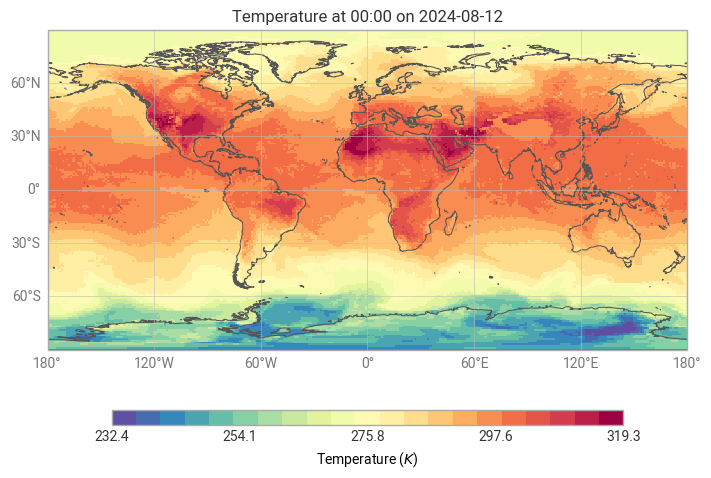

[pyodide]: Loaded 2 new dynamic libraries (202 total for this notebook)


In [6]:
utils.quickplot(ds["t"])